# [Memory](https://langchain-ai.github.io/langgraph/concepts/memory/)
- LangGraph의 Memory는 AI가 대화 내용을 기억할 수 있게 해주는 기능입니다. 
- 사람이 대화할 때 이전에 말한 내용을 기억하는 것처럼, AI도 과거 대화를 기억해서 더 자연스러운 대화를 할 수 있게 해줍니다.


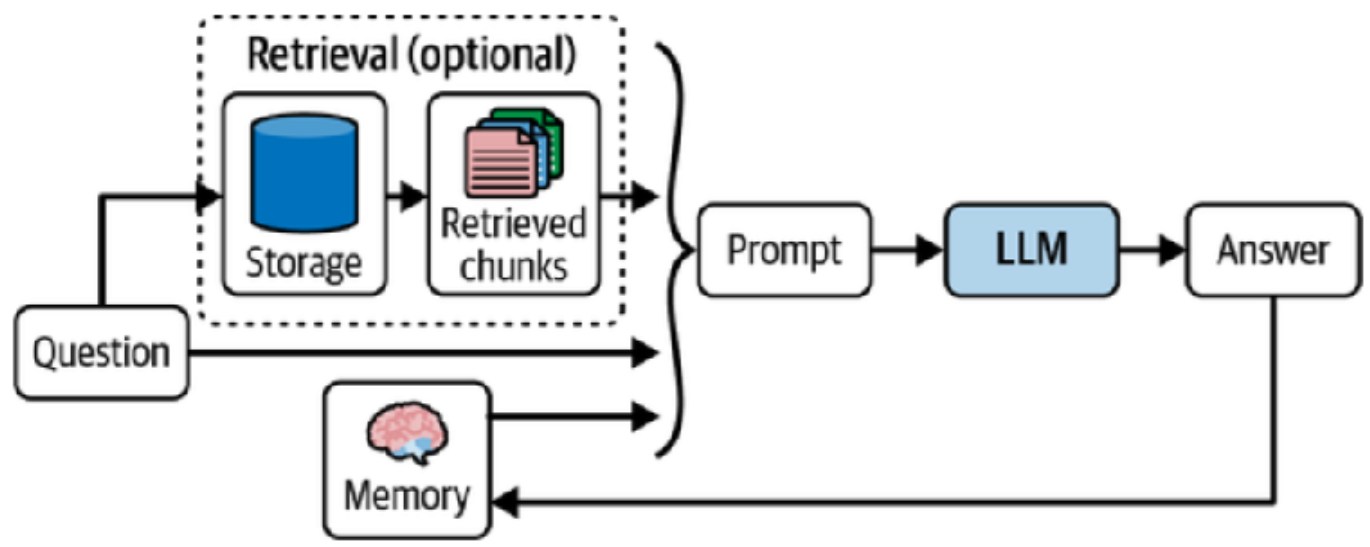

## 왜 Memory가 필요한가요?
> Memory가 없다면:
```text
    사용자: "내 이름은 김철수야"
    AI: "안녕하세요!"

    사용자: "내 이름이 뭐였지?"
    AI: "죄송해요, 모르겠습니다"
```
> Memory가 있다면:
```text
    사용자: "내 이름은 김철수야"
    AI: "안녕하세요 김철수님!"

    사용자: "내 이름이 뭐였지?"
    AI: "김철수님이라고 하셨어요!"
```


# LangGraph Memory 예시들

처음 배우는 학생들을 위한 단계별 예시를 준비했습니다!


## 1. Memory가 적용되지 않은 LangGraph 예시
**이름을 기억하지 못하는 챗봇**

### 1단계: AI 모델 설정
> [Groq API Key](https://console.groq.com/keys)

In [1]:
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
from langchain_groq import ChatGroq

# 정확한 모델 (Precise Model)
# - temperature 낮음 (0.1): 일관되고 정확한 답변
llm = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0.1,
    model_kwargs={
        "top_p":1.0,                     # nucleus sampling (0.8~0.95 권장)
        "frequency_penalty":0.0,         # 반복 억제
        "presence_penalty":0.0,          # 새로운 아이디어 유도
    },
    max_tokens=2000
)

### 2단계: 그래프 노드 정의 (Memory 없음)

In [3]:
from langgraph.graph import MessagesState

def chat_node(state: MessagesState):
    # 현재 메시지만 처리 (이전 대화 기억 안함)
    response = llm.invoke(state["messages"])
    return {"messages": [response]}

### 3단계: 그래프 생성

In [4]:
from langgraph.graph import StateGraph, MessagesState, START, END

graph = StateGraph(MessagesState)

graph.add_node("chat", chat_node)
graph.add_edge(START, "chat")
graph.add_edge("chat", END)

### 4단계: 그래프 컴파일 (Memory 없음)

In [5]:
app_without_memory = graph.compile()

print("Memory 없는 챗봇이 준비되었습니다!")

Memory 없는 챗봇이 준비되었습니다!


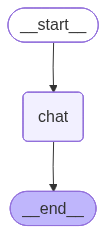

In [6]:
from IPython.display import Image, display

try:
    
    display(
        Image(
            app_without_memory.get_graph().draw_mermaid_png()
        )
    )
except Exception as e:
    print(f"그래프 표시 오류: {e}")

### 5단계: 테스트 

In [7]:
from langchain_core.messages import HumanMessage

# 첫 번째 대화
print("사용자: '내 이름은 김철수야'")
result1 = app_without_memory.invoke(
    {"messages": [HumanMessage(content="내 이름은 김철수야")]})
print(f"AI: {result1['messages'][-1].content}")


사용자: '내 이름은 김철수야'
AI: 반갑습니다, 김철수님! 오늘은 어떤 도움을 드릴까요?


In [8]:
# 두 번째 대화 (새로운 대화)
print("사용자: '내 이름이 뭐였지?'")
result2 = app_without_memory.invoke(
    {"messages": [HumanMessage(content="내 이름이 뭐였지?")]})
print(f"AI: {result2['messages'][-1].content}")

print("\n결과: AI가 이전 대화를 기억하지 못해요!")

사용자: '내 이름이 뭐였지?'
AI: 제가 아직 당신의 이름을 알지 못해요. 혹시 알려주실 수 있나요? 😊

결과: AI가 이전 대화를 기억하지 못해요!


## 2. Memory가 적용된 LangGraph 예시 (MemorySaver)
**이름을 기억하는 똑똑한 챗봇**


### 1단계: AI 모델 설정

In [9]:
from langchain_groq import ChatGroq

# 정확한 모델 (Precise Model)
# - temperature 낮음 (0.1): 일관되고 정확한 답변
llm = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0.1,
    model_kwargs={
        "top_p":1.0,                     # nucleus sampling (0.8~0.95 권장)
        "frequency_penalty":0.0,         # 반복 억제
        "presence_penalty":0.0,          # 새로운 아이디어 유도
    },
    max_tokens=2000
)

### 2단계: 그래프 노드 정의

In [10]:
from langgraph.graph import MessagesState

def chat_node_with_memory(state: MessagesState):
    # 모든 이전 메시지들과 함께 처리 (Memory가 자동으로 관리)
    response = llm.invoke(state["messages"])
    return {"messages": [response]}

### 3단계: 그래프 생성

In [11]:
from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.checkpoint.memory import MemorySaver

graph_with_memory = StateGraph(MessagesState)
graph_with_memory.add_node("chat", chat_node_with_memory)
graph_with_memory.add_edge(START, "chat")
graph_with_memory.add_edge("chat", END)

### 4단계: Memory 저장소 설정 (여기가 핵심!)

In [12]:
# 기존 대화 내용을 저장하는 메모리 서버 생성 
memory = MemorySaver()

# checkpointer=memory
# -> graph에 메모리 서버를 적용시킴으로써 checkpointer가 발생할때 마다(대화가 진행될때 마다) 저장  
app_with_memory = graph_with_memory.compile(checkpointer=memory)

print("Memory가 적용된 챗봇이 준비되었습니다!")

Memory가 적용된 챗봇이 준비되었습니다!


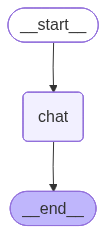

In [13]:
from IPython.display import Image, display

try:
    
    display(
        Image(
            app_with_memory.get_graph().draw_mermaid_png()
        )
    )
except Exception as e:
    print(f"그래프 표시 오류: {e}")

### 5단계: 테스트 

In [14]:
import uuid

# memory_id -> 각 대화별 식별을 할 수 있는 유닉크한 아이디 생성 
memory_id = str(uuid.uuid4())

print(f"유닉크한 아이디 생성: {memory_id}")

유닉크한 아이디 생성: 4bd9d9eb-d9f5-4704-a56e-5ed7042b4dc3


In [15]:
from langchain_core.messages import HumanMessage

# 중요: thread_id -> MemorySaver에서 대화별 아이디 
# 즉 thread_id를 통해서 대화별 내용을 조회/저장 간능 
# MemoryServer가 적용된 경우에는 thread_id는 필수!!!
config = {"configurable": {"thread_id": memory_id}}

print("=== Memory가 적용된 챗봇 테스트 ===")
print(f"config: {config}")

=== Memory가 적용된 챗봇 테스트 ===
config: {'configurable': {'thread_id': '4bd9d9eb-d9f5-4704-a56e-5ed7042b4dc3'}}


In [16]:
# 첫 번째 대화
print("사용자: '내 이름은 김철수야'")
result1 = app_with_memory.invoke(
    {"messages": [HumanMessage(content="내 이름은 김철수야")]}, 
    # 여기가 중요!
    # 정의된 thread_id를 기준으로 대화 이력 데이터를 메모리에 저장
    config=config  
)
print(f"AI: {result1['messages'][-1].content}")

사용자: '내 이름은 김철수야'
AI: 반갑습니다, 김철수님! 어떻게 도와드릴까요?


In [17]:
# 두 번째 대화 (같은 thread_id 사용)
print("사용자: '내 이름이 뭐였지?'")
result2 = app_with_memory.invoke(
    {"messages": [HumanMessage(content="내 이름이 뭐였지?")]}, 
    # 같은 config 사용!
    # 기존에 사용한 thread_id를 이용해서 기존 대화 내용을 메모리에서 조회 
    # 즉, 기존 대화 내용을 바탕으로 사용자의 이름을 알 수 있음!!
    config=config  
)
print(f"AI: {result2['messages'][-1].content}")

print("\n결과: AI가 이전 대화를 기억합니다!")

사용자: '내 이름이 뭐였지?'
AI: 당신의 이름은 **김철수**입니다.

결과: AI가 이전 대화를 기억합니다!


### [Langsmith에서 확인하기](https://smith.langchain.com/)

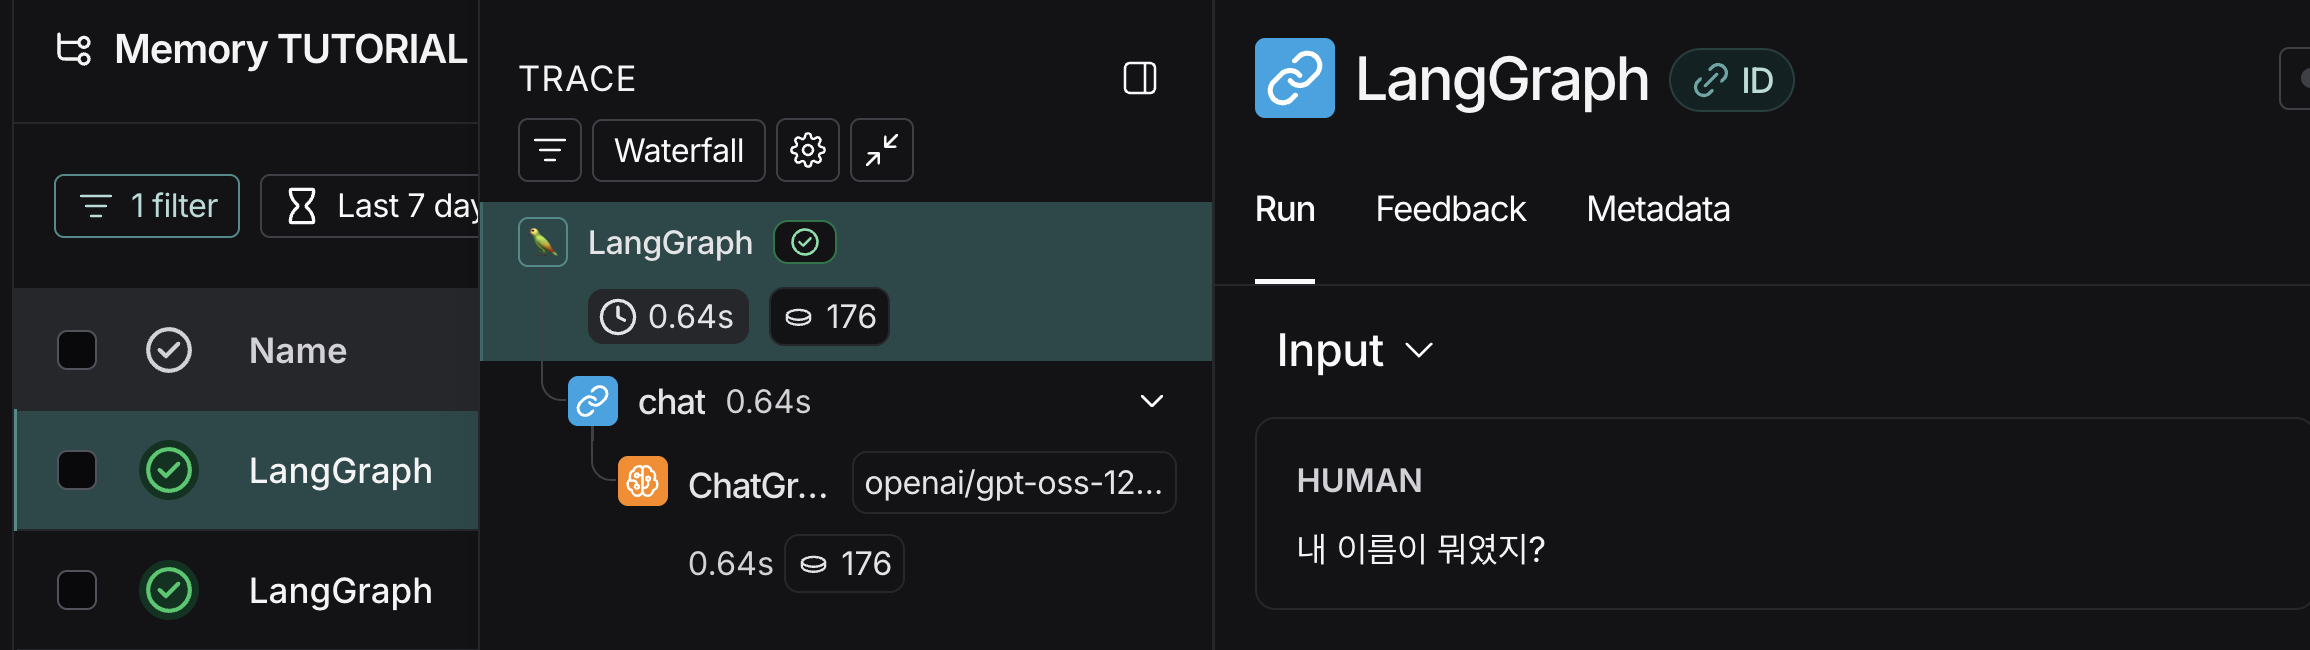